# Column-Level Joinability

Find joinable column pairs across all 2,394 NYC Open Data datasets using pre-computed embeddings.

## Step 1 — Load Data

Load the pre-computed column embeddings, their names, and the raw dataset metadata.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../../data')

# Pre-computed embeddings: shape (24308, 384), one vector per unique column name
embeddings = np.load(DATA_DIR / 'column_embeddings.npy')

# Ordered list of column names corresponding to each row in embeddings
with open(DATA_DIR / 'column_names.json') as f:
    column_names = json.load(f)

# Raw dataset metadata (used to build the reverse lookup in Step 2)
with open(DATA_DIR / 'nyc_socrata_datasets.json') as f:
    raw = json.load(f)

print(f'Embeddings shape:  {embeddings.shape}')
print(f'Column names:      {len(column_names):,}')
print(f'Datasets:          {len(raw):,}')

Embeddings shape:  (24308, 384)
Column names:      24,308
Datasets:          2,394


## Step 2 — Pre-filter Opaque Column Names

NYC Open Data contains many datasets where columns are encoded as machine-generated codes rather than descriptive names. These codes are uninterpretable by the embedding model — it pattern-matches on alphanumeric structure rather than semantic meaning, generating high similarity scores between completely unrelated columns.

We apply a regex pre-filter to remove the following families before computing similarity:

- **Survey matrix codes:** `Q15_C3_R3`, `p_q4e_3`
- **School program encoded:** `selectioncriteria8_prog4`, `admissionspriority39`, `offer_rate9`, `requirement_5_9`, `grade9geapplicants3`
- **Travel survey codes:** `qDAY1TRIPTRAVELCODE04`, `qWORKTRAVELCODE22`, `qDAY1TRIPTRANSITFROM7`
- **Focus/car-type survey codes:** `gCARTYPE1_qCARTYPE3_mA`
- **System/court encoded:** `EVT_UDFCHAR05`, `FJC_Client_59`
- **Numbered-variant columns** (different numbers = different entities, not cross-joinable): `Axle3Weight`, `CouncilDistrict.08`, `Indicator_5.2`, `hh_member_10`, `Pct Level 1`
- **Crime demographic breakdown:** `Fel_Assault_Vic_60_SI`, `Misd_Assault_Rel_Parent`
- **District-numbered admin:** `15 EXPULSIONS`, `30 SUPERINTENDENT`
- **Year-specific columns:** `CY 2011 Consumed`, `FY 2015 Source MMBtu`, `2014-15 9`
- **Date-keyed columns:** `Sept09_PM`, `May-09`

Columns with descriptive names are unaffected.

In [2]:
import re

opaque_patterns = re.compile('|'.join([
    # Survey matrix codes
    r'^[Qq]\d+_[RrCc]\d+',
    r'^[Qq]\d+_\d+$',
    r'^p_q\d+',

    # School program encoded
    r'^selectioncriteria\d+_prog',
    r'^requirement\d+_\d+',
    r'^requirement_\d+_\d+',
    r'^priority\d+_prog',
    r'^admissionspriority\d+',
    r'^admissionsmethod_prog\d+',
    r'^offer_rate\d+',
    r'^geapps_prog\d+',
    r'^seats9ge\d+',
    r'^grade9ge[a-z]+\d+',
    r'^grade9swd[a-z]+\d+',
    r'^swdappsperseat_prog\d+',
    r'^swdapps_prog\d+',
    r'^val_prof_',

    # Travel survey codes
    r'^q[A-Za-z0-9]*travelcode\d+',
    r'^q[A-Za-z0-9]*transit',
    r'^qday\d+trip',

    # Generic survey codes (qBENEFITS01, qBIKETYPE2, etc.)
    r'^q[A-Z]{3,}\d+$',

    # Focus/car-type survey codes (gXXX_qXXX_mX structure)
    r'^g[A-Z]+\d+_q[A-Z]+',
    r'^gFOCUS',

    # System/court encoded
    r'^EVT_UDFCHAR',
    r'^FJC_Client_\d+',

    # Numbered-variant columns (different numbers = different entities, not cross-joinable)
    r'^Axle\d+',
    r'^hh_member_\d+$',
    r'^\w+District\.\d+',
    r'^Indicator_\d+\.\d+',
    r'^Pct\s+Level\s+\d+',
    r'^Height\d+$',
    r'^Charge\s+#\d+:',

    # Crime demographic breakdown (different victim categories = different columns)
    r'^(Fel_|Misd_|Viol_|Hom_)',

    # District-numbered admin columns
    r'^\d+\s+(SUPERINTENDENT|PRINCIPAL|EXPULSIONS|REMOVALS|SUSPENSIONS)',

    # Year/period-specific columns
    r'^(CY|FY)\s*\d{4}',
    r'^\d{4}-\d{2,4}\s+\d+$',

    # Date-keyed column names
    r'^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)\d+_[AP]M$',
    r'^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)-\d+$',
]), re.IGNORECASE)

keep_mask = np.array([not opaque_patterns.search(name) for name in column_names])
filtered_names = [name for name, keep in zip(column_names, keep_mask) if keep]
filtered_embeddings = embeddings[keep_mask]

print(f'Before filter: {len(column_names):,} columns')
print(f'Dropped:       {keep_mask.size - keep_mask.sum():,} opaque columns')
print(f'After filter:  {len(filtered_names):,} columns')
print(f'Embeddings shape: {filtered_embeddings.shape}')

Before filter: 24,308 columns
Dropped:       3,677 opaque columns
After filter:  20,631 columns
Embeddings shape: (20631, 384)


## Step 3 — Build Reverse Lookup

Map each filtered column name to the list of dataset IDs that contain it.
Used later to expand joinable column pairs into dataset pairs.

In [3]:
from collections import defaultdict

filtered_names_set = set(filtered_names)
col_to_datasets = defaultdict(list)

for ds in raw:
    ds_id = ds['id']
    col_details = (ds.get('full_metadata') or {}).get('column_details') or []
    for col in col_details:
        name = col.get('name')
        if name and name in filtered_names_set:
            col_to_datasets[name].append(ds_id)

print(f'Columns in lookup: {len(col_to_datasets):,}')

top = sorted(col_to_datasets.items(), key=lambda x: len(x[1]), reverse=True)[:10]
for name, ds_ids in top:
    print(f'  {name!r:40s} → {len(ds_ids):,} datasets')

Columns in lookup: 20,631
  'Borough'                                → 513 datasets
  'Latitude'                               → 344 datasets
  'Longitude'                              → 342 datasets
  'BBL'                                    → 339 datasets
  'BIN'                                    → 335 datasets
  'Community Board'                        → 291 datasets
  'the_geom'                               → 266 datasets
  'Council District'                       → 245 datasets
  'NTA'                                    → 238 datasets
  'DBN'                                    → 236 datasets


## Step 4 — Compute Column Similarity Matrix

Normalize all filtered embeddings to unit length so that dot product = cosine similarity.
Then compute the full pairwise similarity matrix (~1.8 GB at float32).

In [4]:
import time

emb = filtered_embeddings.astype(np.float32)
norms = np.linalg.norm(emb, axis=1, keepdims=True)
normalized = emb / norms

t0 = time.time()
sim_matrix = normalized @ normalized.T
print(f'Computed in {time.time() - t0:.1f}s')
print(f'Matrix shape: {sim_matrix.shape}')
print(f'Memory usage: {sim_matrix.nbytes / 1e9:.2f} GB')

Computed in 2.8s
Matrix shape: (20631, 20631)
Memory usage: 1.70 GB


## Step 5 — Analyze Distribution & Pick Threshold

Total column pairs: 212,808,765


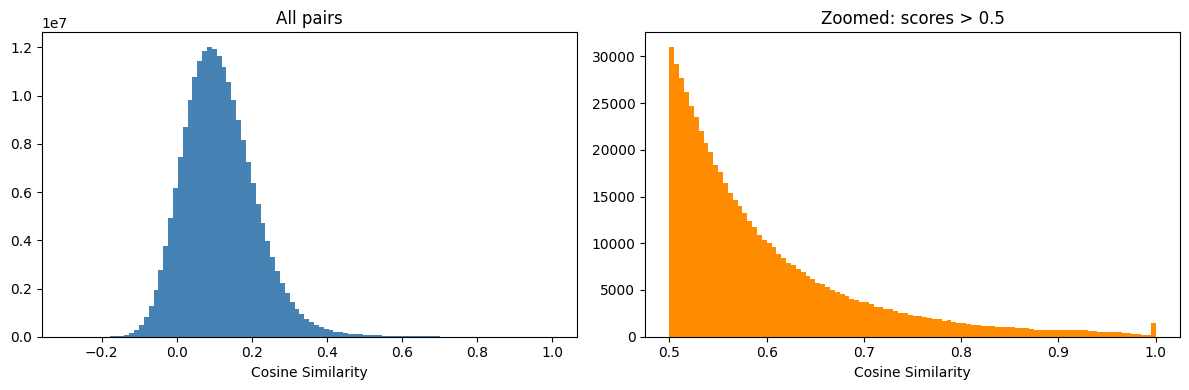

  > 0.60:    206,519 pairs  (0.10%)
  > 0.65:    127,164 pairs  (0.06%)
  > 0.70:     79,894 pairs  (0.04%)
  > 0.75:     50,056 pairs  (0.02%)
  > 0.80:     31,349 pairs  (0.01%)
  > 0.85:     19,465 pairs  (0.01%)
  > 0.90:     11,126 pairs  (0.01%)


In [5]:
# Extract upper triangle only (exclude diagonal = self-similarity)
upper_idx = np.triu_indices(len(sim_matrix), k=1)
scores = sim_matrix[upper_idx]

print(f'Total column pairs: {len(scores):,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scores, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('All pairs')
axes[0].set_xlabel('Cosine Similarity')

axes[1].hist(scores[scores > 0.5], bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('Zoomed: scores > 0.5')
axes[1].set_xlabel('Cosine Similarity')

plt.tight_layout()
plt.show()

for t in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
    n = (scores > t).sum()
    print(f'  > {t:.2f}: {n:>10,} pairs  ({n/len(scores):.2%})')

In [6]:
np.random.seed(42)
col_names_arr = np.array(filtered_names)

for low, high in [(0.70, 0.75), (0.75, 0.80), (0.80, 0.85), (0.85, 0.90), (0.90, 1.00)]:
    mask = (scores >= low) & (scores < high)
    idxs = np.where(mask)[0]
    sample = np.random.choice(idxs, size=min(8, len(idxs)), replace=False)
    print(f'\n--- {low:.2f} – {high:.2f} ({len(idxs):,} pairs) ---')
    for idx in sample:
        i, j = upper_idx[0][idx], upper_idx[1][idx]
        print(f'  {col_names_arr[i]!r:45s}  ↔  {col_names_arr[j]!r:45s}  ({scores[idx]:.3f})')


--- 0.70 – 0.75 (29,838 pairs) ---
  np.str_('2011')                                ↔  np.str_('(FY 2012)7/1/2011')                   (0.716)
  np.str_('BROOKLYN â\x80\x93 CONDOMINIUMS COMPARABLE PROPERTIES â\x80\x93 Estimated Expense')  ↔  np.str_('MANHATTAN â\x80\x93 CONDOMINIUMS COMPARABLE PROPERTIES â\x80\x93 Gross SqFt')  (0.719)
  np.str_('FILING_NUMBER')                       ↔  np.str_('Filed_Stat')                          (0.703)
  np.str_('Grade 04 1')                          ↔  np.str_('Grade')                               (0.730)
  np.str_('PermitAllowedTo')                     ↔  np.str_('Permittee')                           (0.741)
  np.str_('Grade level')                         ↔  np.str_('Grade 02 1')                          (0.708)
  np.str_('Multifamily Housing - Gross Floor Area (ft²)')  ↔  np.str_('Barracks- Gross Floor Area (ft²)')    (0.705)
  np.str_('Date Collected')                      ↔  np.str_('COLLECTION_DATE')                     (0.713)

--- 0.75 

### Threshold Decision

After pre-filtering opaque column names, we set **threshold = 0.85**.

At this level, spot-checking consistently finds genuine pairs — `INSPECTION_DATE` ↔ `InspectionDate`, `Borough Block Lot` ↔ `BOROUGH/BLOCK/LOT #`, `Date Received` ↔ `Date_Received`. Residual noise remains from long survey question text (similar sentence structure across different questions) and a small number of encoded patterns not caught by the regex filter. These are accepted as a known limitation of embedding-based approaches on this dataset and noted in the report.

## Step 6 — Filter & Expand to Dataset Pairs

For each column pair above the threshold, use the reverse lookup to find all cross-dataset combinations.

In [7]:
THRESHOLD = 0.85

upper_idx = np.triu_indices(len(sim_matrix), k=1)
above = np.where(sim_matrix[upper_idx] >= THRESHOLD)[0]

print(f'Column pairs above {THRESHOLD}: {len(above):,}')

col_names_arr = np.array(filtered_names)
rows = []

for idx in above:
    i, j = upper_idx[0][idx], upper_idx[1][idx]
    col_a, col_b = col_names_arr[i], col_names_arr[j]
    score = float(sim_matrix[i, j])

    datasets_a = col_to_datasets.get(col_a, [])
    datasets_b = col_to_datasets.get(col_b, [])

    for ds_a in datasets_a:
        for ds_b in datasets_b:
            if ds_a != ds_b:
                rows.append({
                    'dataset_id_1': ds_a,
                    'column_name_1': col_a,
                    'dataset_id_2': ds_b,
                    'column_name_2': col_b,
                    'score': round(score, 4),
                    'method': 'embedding',
                })

print(f'Dataset-level rows after expansion: {len(rows):,}')

Column pairs above 0.85: 19,465
Dataset-level rows after expansion: 675,202


## Step 7 — Save

In [ ]:
df = pd.DataFrame(rows)

# fastparquet requires object dtype strings, not Arrow-backed strings (pandas 3+)
for col in ['dataset_id_1', 'column_name_1', 'dataset_id_2', 'column_name_2', 'method']:
    df[col] = df[col].astype(object)
 
df.to_parquet(DATA_DIR / 'joinability_pairs_embedding_column_level.parquet', index=False, engine='fastparquet')

print(f'Saved {len(df):,} rows')
print(df.head(10))

Saved 675,202 rows
  dataset_id_1 column_name_1 dataset_id_2 column_name_2  score     method
0    eccv-9dzr          Time    wewp-mm3p          TIME    1.0  embedding
1    knr6-vurn          Time    wewp-mm3p          TIME    1.0  embedding
2    icbf-663g          Time    wewp-mm3p          TIME    1.0  embedding
3    56e3-rp8d          Time    wewp-mm3p          TIME    1.0  embedding
4    6pwv-zmgh          Time    wewp-mm3p          TIME    1.0  embedding
5    eccv-9dzr          Time    auuc-fqzi          time    1.0  embedding
6    knr6-vurn          Time    auuc-fqzi          time    1.0  embedding
7    icbf-663g          Time    auuc-fqzi          time    1.0  embedding
8    56e3-rp8d          Time    auuc-fqzi          time    1.0  embedding
9    6pwv-zmgh          Time    auuc-fqzi          time    1.0  embedding
